# Analyse descriptive — Profils de performance des joueurs (Coupe du Monde 2026)

Ce notebook part des données nettoyées (`players_clean.csv`, produit par le notebook
`01_nettoyage.ipynb`) pour répondre aux quatre sous-questions de la problématique :

1. Comment se distribuent les statistiques individuelles des joueurs ?
2. Ces profils varient-ils selon le poste occupé ?
3. Observe-t-on des différences selon la confédération d'origine ?
4. La performance est-elle corrélée à la valeur marchande ?


## 0. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

players = pd.read_csv('../data/players_clean.csv')
print("Table joueur :", players.shape)
players.head()


Table joueur : (1248, 60)


,player_id,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,...,nationality,confederation,team,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,n_matches
0,P00001,953,0,0,0,0,0.00,0.00,4,164,...,French,UEFA,France,Goalkeeper,191,81,Right,PSV Eindhoven,16574124,34
1,P00002,830,0,0,0,0,0.00,0.00,6,154,...,French,UEFA,France,Goalkeeper,190,84,Right,Anderlecht,53959475,34
2,P00003,922,0,0,0,0,0.00,0.00,1,150,...,French,UEFA,France,Goalkeeper,191,77,Right,Besiktas,4935397,34
3,P00004,1299,0,0,8,1,0.06,0.01,9,472,...,French,UEFA,France,Defender,183,80,Right,Bayer Leverkusen,3795900,34
4,P00005,1298,0,2,7,0,0.18,0.20,12,873,...,French,UEFA,France,Defender,188,79,Right,Borussia Dortmund,21832889,34


## 1. Sélection des variables pertinentes

Comme discuté, on ne travaille pas sur les 60 colonnes disponibles mais sur un
sous-ensemble pertinent pour la problématique : identité, performance offensive,
défensive, passes, volume de jeu, et scores synthétiques.


In [2]:
cols_identity = ['player_id', 'player_name', 'age', 'position', 'nationality',
                  'confederation', 'market_value_eur']

cols_offense = ['goals', 'assists', 'shots', 'shots_on_target',
                'expected_goals_xg', 'expected_assists_xa', 'key_passes']

cols_defense = ['tackles', 'interceptions', 'clearances', 'blocks',
                 'recoveries', 'defensive_actions']

cols_passing = ['successful_passes', 'total_passes', 'pass_accuracy']

cols_volume = ['minutes_played', 'n_matches']

cols_scores = ['player_rating', 'performance_score', 'offensive_contribution',
               'defensive_contribution', 'consistency_score']

analysis_cols = (cols_identity + cols_offense + cols_defense +
                  cols_passing + cols_volume + cols_scores)

data = players[analysis_cols].copy()
print(data.shape)
data.head()


(1248, 30)


,player_id,player_name,age,position,nationality,confederation,market_value_eur,goals,assists,shots,...,successful_passes,total_passes,pass_accuracy,minutes_played,n_matches,player_rating,performance_score,offensive_contribution,defensive_contribution,consistency_score
0,P00001,Kylian Griezmann,24,Goalkeeper,French,UEFA,16574124,0,0,0,...,164,232,0.731176,953,34,2.329412,23.829412,9.376471,80.473529,69.691176
1,P00002,Antoine Tchouameni,29,Goalkeeper,French,UEFA,53959475,0,0,0,...,154,217,0.728824,830,34,1.961765,20.323529,11.152941,97.435294,87.241176
2,P00003,Ousmane Hernandez,24,Goalkeeper,French,UEFA,4935397,0,0,0,...,150,234,0.708529,922,34,2.038235,21.750000,11.205882,79.588235,70.752941
3,P00004,Kylian Camavinga,27,Defender,French,UEFA,3795900,0,0,8,...,472,591,0.811765,1299,34,3.473529,35.861765,23.958824,54.952941,49.800000
4,P00005,Antoine Kounde,24,Defender,French,UEFA,21832889,0,2,7,...,873,1078,0.821765,1298,34,4.270588,43.147059,48.211765,94.000000,87.211765


## 2. Distribution des statistiques individuelles (sous-question 1)

### 2.1 Statistiques descriptives générales


In [3]:
desc_vars = ['age', 'goals', 'assists', 'minutes_played', 'shots',
             'pass_accuracy', 'player_rating', 'market_value_eur']

data[desc_vars].describe().T


,count,mean,std,min,25%,50%,75%,max
age,1248.0,2.630369e+01,4.071130e+00,17.000000,2.375000e+01,2.600000e+01,2.900000e+01,3.900000e+01
goals,1248.0,2.423077e+00,3.003422e+00,0.000000,0.000000e+00,1.000000e+00,3.000000e+00,2.400000e+01
assists,1248.0,2.290865e+00,2.266774e+00,0.000000,1.000000e+00,2.000000e+00,3.000000e+00,1.300000e+01
minutes_played,1248.0,1.583742e+03,3.902869e+02,472.000000,1.320750e+03,1.567500e+03,1.829000e+03,3.121000e+03
shots,1248.0,1.955849e+01,1.778026e+01,0.000000,8.000000e+00,1.400000e+01,2.800000e+01,1.050000e+02
pass_accuracy,1248.0,8.083803e-01,4.174996e-02,0.688529,7.821807e-01,8.190000e-01,8.430025e-01,8.742105e-01
player_rating,1248.0,3.633741e+00,7.782367e-01,0.838636,3.311111e+00,3.712712e+00,4.108511e+00,5.706977e+00
market_value_eur,1248.0,1.985090e+07,2.666142e+07,528822.000000,4.382494e+06,1.019278e+07,2.286937e+07,2.000000e+08


### 2.2 Asymétrie des distributions (skewness)

La moyenne et la médiane du tableau précédent laissent déjà deviner que certaines variables ne sont pas distribuées symétriquement. On quantifie cela avec le coefficient d'asymétrie (skewness) : proche de 0 = distribution symétrique, positif = étalement vers les valeurs hautes, négatif = étalement vers les valeurs basses.

In [4]:
skew_table = data[desc_vars].skew().sort_values(ascending=False).rename('skewness')
skew_table.to_frame().round(2)

,skewness
market_value_eur,2.96
goals,1.87
shots,1.48
assists,1.27
minutes_played,0.26
age,0.10
player_rating,-0.78
pass_accuracy,-0.90


**Lecture** :
- `market_value_eur` (skewness ≈ 3) et `goals` (≈ 1,9) sont fortement asymétriques vers la droite : quelques joueurs (superstars, buteurs prolifiques) tirent la moyenne bien au-dessus de la médiane. Cela justifie de privilégier la **médiane** plutôt que la moyenne pour résumer ces variables, et d'utiliser une **échelle logarithmique** pour la valeur marchande dans les graphiques et modèles (section 5).
- `pass_accuracy` et `player_rating` ont une asymétrie négative modérée : la majorité des joueurs sont regroupés en haut de l'échelle, avec une minorité de valeurs plus faibles (souvent des joueurs ayant peu joué).
- `age` et `minutes_played` sont proches de la symétrie (skewness proche de 0).

### 2.3 Visualisation des distributions

On regarde en particulier `goals`, `minutes_played`, `player_rating` et
`market_value_eur` (cette dernière étant probablement très asymétrique).


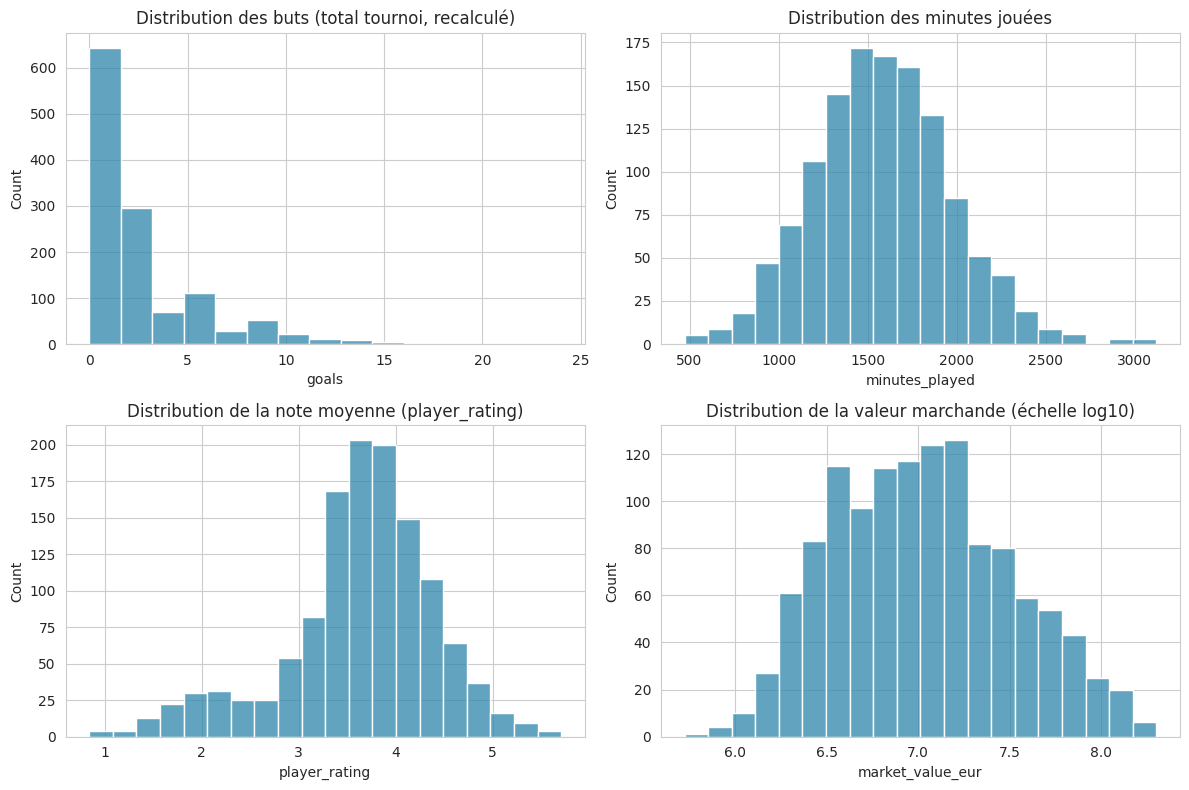

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data['goals'], bins=15, ax=axes[0,0], color='#2E86AB')
axes[0,0].set_title('Distribution des buts (total tournoi, recalculé)')

sns.histplot(data['minutes_played'], bins=20, ax=axes[0,1], color='#2E86AB')
axes[0,1].set_title('Distribution des minutes jouées')

sns.histplot(data['player_rating'], bins=20, ax=axes[1,0], color='#2E86AB')
axes[1,0].set_title('Distribution de la note moyenne (player_rating)')

sns.histplot(np.log10(data['market_value_eur']), bins=20, ax=axes[1,1], color='#2E86AB')
axes[1,1].set_title('Distribution de la valeur marchande (échelle log10)')

plt.tight_layout()
plt.show()


**Constat attendu** : `goals` et `assists` sont fortement asymétriques (beaucoup de
joueurs à 0 ou peu de buts, quelques attaquants très prolifiques) — cohérent avec la
nature du football où seule une minorité de joueurs marque beaucoup. La valeur marchande
est également très asymétrique, d'où l'usage d'une échelle logarithmique.


## 3. Comparaison par poste (sous-question 2)

### 3.1 Visualisation


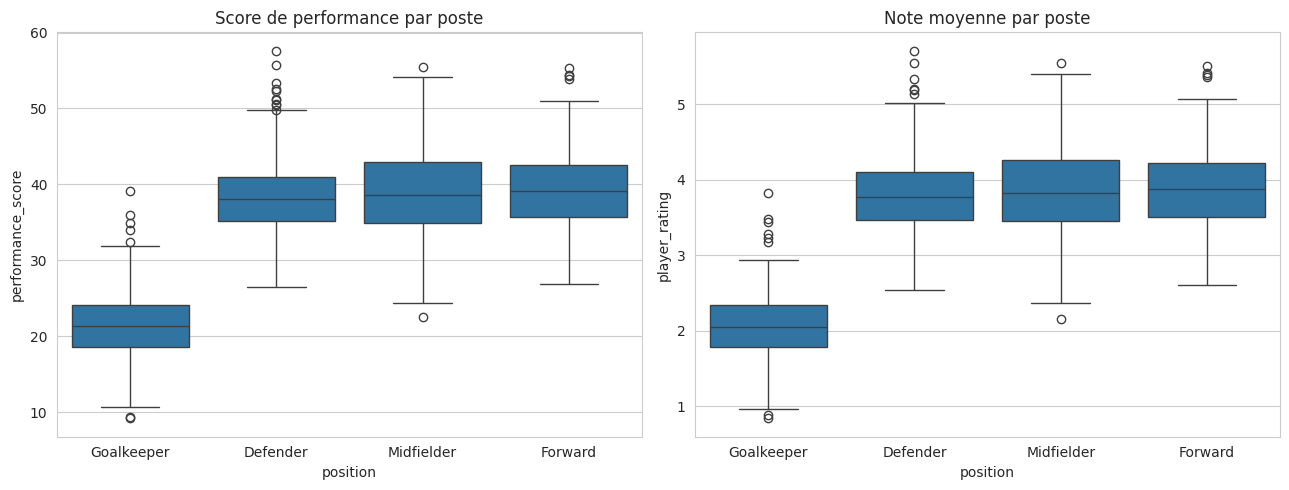

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']

sns.boxplot(data=data, x='position', y='performance_score', order=order, ax=axes[0])
axes[0].set_title('Score de performance par poste')

sns.boxplot(data=data, x='position', y='player_rating', order=order, ax=axes[1])
axes[1].set_title('Note moyenne par poste')

plt.tight_layout()
plt.show()


### 3.3 Test statistique

Les gardiens ayant un profil offensif structurellement différent (peu ou pas de buts,
tirs...), on utilise un test non paramétrique (Kruskal-Wallis) plutôt qu'une ANOVA
classique, plus robuste si les distributions ne sont pas normales.


### 3.2 Vérification des conditions du test

Avant de choisir entre une ANOVA classique (paramétrique) et un test de Kruskal-Wallis (non paramétrique), on vérifie les deux conditions requises par l'ANOVA :
1. **Normalité** de la variable dans chaque groupe (test de Shapiro-Wilk) ;
2. **Homogénéité des variances** entre groupes (test de Levene).

Si l'une de ces conditions n'est pas respectée, le test de Kruskal-Wallis est préférable car il ne fait aucune hypothèse sur la distribution des données.

In [7]:
groups_position = [data.loc[data['position'] == p, 'performance_score']
                    for p in order]

print("Test de Shapiro-Wilk : normalité de performance_score par poste\n")
for pos in order:
    sub = data.loc[data['position'] == pos, 'performance_score']
    stat, p = stats.shapiro(sub)
    verdict = 'normal (p > 0.05)' if p > 0.05 else 'NON normal (p <= 0.05)'
    print(f"{pos:12s} n={len(sub):4d}  W={stat:.4f}  p={p:.4g}  -> {verdict}")

print("\nTest de Levene : homogénéité des variances entre postes\n")
stat, p = stats.levene(*groups_position)
verdict = 'variances égales (p > 0.05)' if p > 0.05 else 'variances INÉGALES (p <= 0.05)'
print(f"W={stat:.3f}  p={p:.4g}  -> {verdict}")

Test de Shapiro-Wilk : normalité de performance_score par poste

Goalkeeper   n= 144  W=0.9763  p=0.01345  -> NON normal (p <= 0.05)
Defender     n= 432  W=0.9857  p=0.0002991  -> NON normal (p <= 0.05)
Midfielder   n= 384  W=0.9953  p=0.294  -> normal (p > 0.05)
Forward      n= 288  W=0.9923  p=0.1429  -> normal (p > 0.05)

Test de Levene : homogénéité des variances entre postes

W=4.330  p=0.004797  -> variances INÉGALES (p <= 0.05)


**Signification** :
Les scores de performance des gardiens et des défenseurs ne suivent pas une distribution normale (p < 0,05), et les variances diffèrent significativement entre postes (test de Levene, p = 0,0048). **Les deux conditions de l'ANOVA classique sont donc violées** : le test de Kruskal-Wallis, qui ne suppose ni normalité ni égalité des variances, est le choix statistiquement justifié pour comparer les postes.

In [8]:
h_stat, p_value = stats.kruskal(*groups_position)
print(f"Test de Kruskal-Wallis (performance_score ~ position)")
print(f"H = {h_stat:.2f}, p-value = {p_value:.4g}")

if p_value < 0.05:
    print("-> Différence significative entre postes (seuil 5%).")
else:
    print("-> Pas de différence significative détectée entre postes (seuil 5%).")


Test de Kruskal-Wallis (performance_score ~ position)
H = 368.40, p-value = 1.545e-79
-> Différence significative entre postes (seuil 5%).


**Signification** :
La p-value obtenue (1,5 × 10⁻⁷⁹) est extrêmement inférieure au seuil de 5 % (0,05) : on peut affirmer avec une très grande confiance que le score de performance **diffère selon le poste occupé**. Cela confirme statistiquement l'intuition footballistique : gardiens, défenseurs, milieux et attaquants ont des rôles différents, donc des profils de performance différents.

⚠️ Ce test dit seulement qu'*il existe* une différence entre postes, pas *entre quels postes précisément* ni *quelle est l'ampleur* de cette différence. C'est pour cela qu'on complète avec les boxplots (visuel) et le tableau de contributions offensive/défensive (section 3.3) juste après, qui apportent le contenu concret.

### 3.4 Profils offensif / défensif par poste

Pour caractériser plus finement les "logiques de jeu" par poste, on compare la
contribution offensive et défensive moyenne.


In [9]:
profile_by_position = data.groupby('position')[
    ['offensive_contribution', 'defensive_contribution', 'goals', 'assists',
     'tackles', 'interceptions']
].mean().round(2).reindex(order)

profile_by_position


,offensive_contribution,defensive_contribution,goals,assists,tackles,interceptions
position,,,,,,
Goalkeeper,10.10,69.31,0.00,0.36,0.00,5.90
Defender,32.24,67.31,0.82,1.05,57.31,47.19
Midfielder,56.01,50.91,2.26,3.56,38.75,28.31
Forward,65.40,24.90,6.27,3.43,14.54,7.44


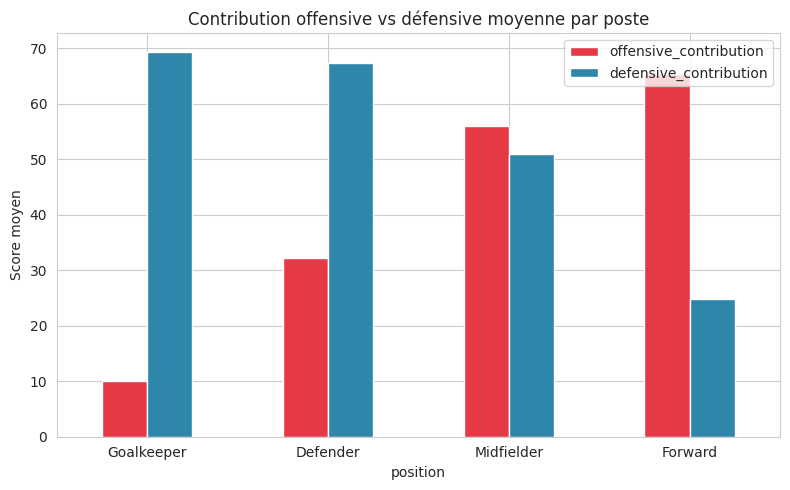

In [10]:
profile_by_position[['offensive_contribution', 'defensive_contribution']].plot(
    kind='bar', figsize=(8,5), color=['#E63946', '#2E86AB']
)
plt.title('Contribution offensive vs défensive moyenne par poste')
plt.ylabel('Score moyen')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Signification** :
Le tableau ci-dessus caractérise très concrètement les "logiques de jeu" par poste évoquées dans le titre de l'étude :
- Les **attaquants** ont la contribution offensive la plus forte (65,4) et la plus faible contribution défensive (24,9) — logique, leur rôle est de marquer, pas de défendre.
- Les **défenseurs** ont le profil inverse : forte contribution défensive (67,3), beaucoup de tacles (57,3) et d'interceptions (47,2), mais peu de buts (0,82) et d'assists (1,05).
- Les **milieux** ont un profil intermédiaire et équilibré (56 en attaque, 51 en défense) — cohérent avec leur rôle de relais entre les deux blocs.
- Les **gardiens** ont, sans surprise, une contribution offensive quasi nulle (10,1) et la plus forte contribution "défensive" au sens large (69,3, dominée par les arrêts).

**Pour votre étude** : ce tableau permet de répondre concrètement à la sous-question 2 en donnant un contenu chiffré aux "profils de performance" par poste, au-delà du simple constat qu'ils diffèrent statistiquement (section 3.2).

## 4. Comparaison par confédération (sous-question 3)

### 4.1 Visualisation


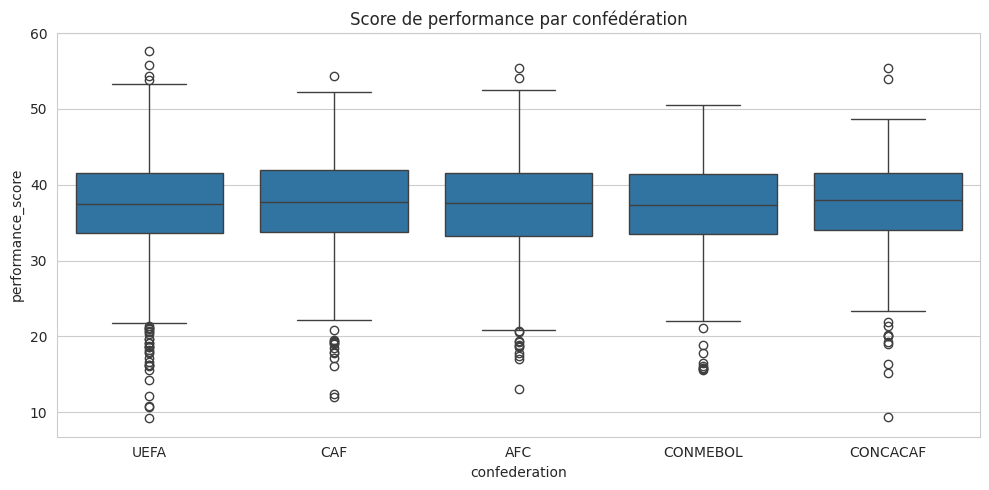

In [11]:
order_conf = data['confederation'].value_counts().index.tolist()

plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='confederation', y='performance_score', order=order_conf)
plt.title('Score de performance par confédération')
plt.tight_layout()
plt.show()


### 4.3 Test statistique


### 4.2 Vérification des conditions du test

Même démarche que pour la comparaison par poste : on vérifie la normalité par groupe et l'homogénéité des variances avant de choisir le test adapté.

In [12]:
groups_conf = [data.loc[data['confederation'] == c, 'performance_score']
               for c in order_conf]

print("Test de Shapiro-Wilk : normalité de performance_score par confédération\n")
for conf in order_conf:
    sub = data.loc[data['confederation'] == conf, 'performance_score']
    stat, p = stats.shapiro(sub)
    verdict = 'normal (p > 0.05)' if p > 0.05 else 'NON normal (p <= 0.05)'
    print(f"{conf:12s} n={len(sub):4d}  W={stat:.4f}  p={p:.4g}  -> {verdict}")

print("\nTest de Levene : homogénéité des variances entre confédérations\n")
stat, p = stats.levene(*groups_conf)
verdict = 'variances égales (p > 0.05)' if p > 0.05 else 'variances INÉGALES (p <= 0.05)'
print(f"W={stat:.3f}  p={p:.4g}  -> {verdict}")

Test de Shapiro-Wilk : normalité de performance_score par confédération

UEFA         n= 468  W=0.9616  p=1.04e-09  -> NON normal (p <= 0.05)
CAF          n= 234  W=0.9465  p=1.405e-07  -> NON normal (p <= 0.05)
AFC          n= 208  W=0.9679  p=0.0001132  -> NON normal (p <= 0.05)
CONMEBOL     n= 182  W=0.9424  p=1.082e-06  -> NON normal (p <= 0.05)
CONCACAF     n= 156  W=0.9238  p=2.405e-07  -> NON normal (p <= 0.05)

Test de Levene : homogénéité des variances entre confédérations

W=0.816  p=0.5149  -> variances égales (p > 0.05)


**Signification** :
Les 5 confédérations présentent toutes une distribution non normale du score de performance (p < 0,001 dans chaque cas), bien que les variances soient homogènes entre groupes (test de Levene, p = 0,51). La condition de normalité étant violée, **Kruskal-Wallis reste le test approprié**, même si l'homogénéité des variances aurait, seule, autorisé une ANOVA classique.

In [13]:
h_stat, p_value = stats.kruskal(*groups_conf)
print(f"Test de Kruskal-Wallis (performance_score ~ confédération)")
print(f"H = {h_stat:.2f}, p-value = {p_value:.4g}")

if p_value < 0.05:
    print("-> Différence significative entre confédérations (seuil 5%).")
else:
    print("-> Pas de différence significative détectée entre confédérations (seuil 5%).")


Test de Kruskal-Wallis (performance_score ~ confédération)
H = 0.72, p-value = 0.9489
-> Pas de différence significative détectée entre confédérations (seuil 5%).


**Signification** :
La p-value obtenue (0,95) est très largement supérieure au seuil de 5 % : on ne détecte **aucune différence statistiquement significative** de performance entre confédérations dans ce jeu de données. Autrement dit, à ce niveau d'analyse, un joueur UEFA n'est pas, en moyenne, plus ou moins performant qu'un joueur CAF, CONMEBOL, AFC ou CONCACAF.

**Pour votre étude** : c'est un résultat qui répond directement (et négativement) à la sous-question 3. C'est un résultat tout à fait publiable et intéressant en soi — l'absence de différence est une conclusion, pas un échec de l'analyse. On peut cependant nuancer ce résultat avec le déséquilibre des effectifs vu juste après (468 joueurs UEFA contre seulement 156 CONCACAF), qui peut réduire la puissance du test pour les confédérations les moins représentées.

**Point de vigilance** : le nombre de joueurs par confédération n'est pas égal
(l'UEFA est historiquement sur-représentée dans un Mondial). Ce déséquilibre d'effectifs
sera mentionné comme limite d'interprétation.


In [14]:
data['confederation'].value_counts()


confederation
UEFA        468
CAF         234
AFC         208
CONMEBOL    182
CONCACAF    156
Name: count, dtype: int64

**Signification** :
Les effectifs sont très déséquilibrés : l'UEFA représente **468 joueurs** (37 % de l'échantillon) contre seulement **156 pour la CONCACAF** (12 %). Ce déséquilibre est cohérent avec la composition réelle d'un Mondial à 48 équipes (plus de places qualificatives pour l'Europe) mais il faut le garder en tête : le test statistique précédent a moins de puissance pour détecter une éventuelle différence chez les confédérations les moins représentées. C'est une limite à mentionner dans la Documentation, pas une raison de rejeter le résultat.

## 5. Valeur marchande vs performance réelle (sous-question 4)

### 5.1 Visualisation


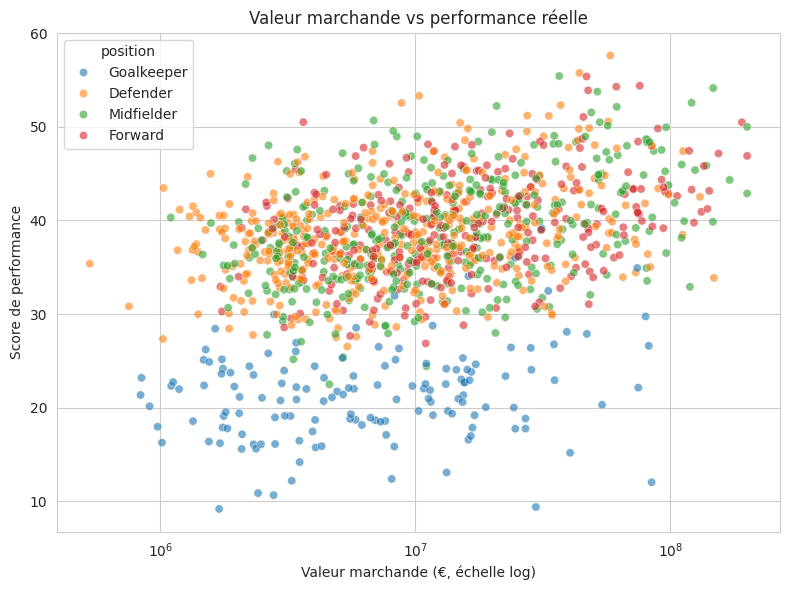

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='market_value_eur', y='performance_score',
                 hue='position', alpha=0.6)
plt.xscale('log')
plt.xlabel('Valeur marchande (€, échelle log)')
plt.ylabel('Score de performance')
plt.title('Valeur marchande vs performance réelle')
plt.tight_layout()
plt.show()


### 5.2 Corrélation


In [16]:
data['log_market_value'] = np.log10(data['market_value_eur'])

pearson_r, pearson_p = stats.pearsonr(data['log_market_value'], data['performance_score'])
spearman_r, spearman_p = stats.spearmanr(data['market_value_eur'], data['performance_score'])

print(f"Corrélation de Pearson (log valeur marchande, performance) : r = {pearson_r:.3f}, p = {pearson_p:.4g}")
print(f"Corrélation de Spearman (valeur marchande, performance)    : rho = {spearman_r:.3f}, p = {spearman_p:.4g}")


Corrélation de Pearson (log valeur marchande, performance) : r = 0.361, p = 1.03e-39
Corrélation de Spearman (valeur marchande, performance)    : rho = 0.362, p = 6.09e-40


**Signification** :
Les deux coefficients (Pearson r = 0,361 et Spearman ρ = 0,362, tous deux avec p < 0,001) sont très proches, ce qui indique que la relation entre valeur marchande et performance est bien captée même sans hypothèse de linéarité stricte.

**Comment lire 0,36 concrètement** : sur une échelle de 0 (aucun lien) à 1 (lien parfait), 0,36 correspond à une **corrélation positive mais modérée**. Si on élève ce chiffre au carré (0,36² ≈ 0,13), on obtient que la valeur marchande seule n'explique qu'environ **13 % de la variabilité** du score de performance. Autrement dit : la réputation/valeur marchande d'un joueur est bien liée à sa performance réelle sur le tournoi, mais très loin de la déterminer entièrement — d'autres facteurs (poste, forme du moment, contexte de l'équipe...) jouent un rôle au moins aussi important. C'est une réponse nuancée à la sous-question 4.

### 5.3 Régression multiple

On contrôle par âge et poste, pour isoler l'effet propre de la valeur marchande sur la
performance.


In [17]:
model = smf.ols(
    'performance_score ~ log_market_value + age + C(position)',
    data=data
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      performance_score   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.586
Method:                 Least Squares   F-statistic:                     353.9
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          7.09e-236
Time:                        14:18:48   Log-Likelihood:                -3757.2
No. Observations:                1248   AIC:                             7526.
Df Residuals:                    1242   BIC:                             7557.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

**Signification (lecture des résultats obtenus)** :

- **R² = 0,588** : le modèle (valeur marchande + âge + poste) explique **58,8 % de la variance** du score de performance. C'est un modèle qui explique une bonne part du phénomène, mais qui laisse encore 41 % inexpliqués par des facteurs non inclus ici (forme physique, contexte de l'équipe, adversité rencontrée...).
- **`log_market_value` : coefficient = 4,01, p < 0,001** → à poste et âge égaux, chaque multiplication par 10 de la valeur marchande est associée à une hausse d'environ 4 points du score de performance. La relation reste donc significative **même après avoir contrôlé le poste**, ce qui renforce la conclusion de la section 5.2 : le lien valeur marchande/performance n'est pas un simple artefact du fait que certains postes coûtent plus cher.
- **`C(position)[T.Goalkeeper]` = -16,5, p < 0,001** : à valeur marchande et âge égaux, être gardien plutôt que défenseur (catégorie de référence) est associé à un score de performance inférieur de 16,5 points. Ceci reflète surtout que `performance_score` valorise des actions offensives/globales peu accessibles aux gardiens, plus qu'un vrai jugement de valeur sur leur niveau de jeu.
- **`age` : coefficient quasi nul (0,026), p = 0,459 (non significatif)** : à valeur marchande et poste égaux, l'âge n'a pas d'effet mesurable sur la performance dans ce tournoi. Cela suggère que ni les jeunes ni les joueurs expérimentés n'ont un avantage systématique une fois la réputation et le poste pris en compte.

**Réponse synthétique à la sous-question 4** : oui, la valeur marchande est significativement associée à la performance réelle, mais l'ampleur du lien reste modérée (R² < 0,6) — la réputation préalable d'un joueur n'est donc qu'un indicateur partiel de sa performance effective sur le tournoi.

## 6. Cas particulier des gardiens

Les gardiens ayant un profil de performance très différent (pas de buts/tirs), on
regarde leurs statistiques spécifiques séparément.


In [18]:
goalkeepers = players[players['position'] == 'Goalkeeper']

gk_vars = ['saves', 'save_percentage', 'clean_sheet', 'goals_conceded', 'player_rating']
goalkeepers[gk_vars].describe().T


,count,mean,std,min,25%,50%,75%,max
saves,144.0,45.986111,13.699056,15.000000,36.750000,45.000000,53.000000,87.000000
save_percentage,144.0,0.227574,0.053873,0.100455,0.193844,0.233368,0.261092,0.387391
clean_sheet,144.0,3.479167,1.777752,0.000000,2.000000,3.000000,5.000000,8.000000
goals_conceded,144.0,18.444444,6.875290,6.000000,14.000000,17.000000,22.250000,38.000000
player_rating,144.0,2.067989,0.504415,0.838636,1.782273,2.044738,2.333517,3.821053


**Signification** :
- **144 gardiens** dans l'échantillon (soit 3 par équipe en moyenne, cohérent avec une liste de 48 équipes × ~3 gardiens).
- **`save_percentage` moyen ≈ 23 %** : à première vue ce chiffre paraît bas comparé aux standards habituels du football (souvent 65-75 % en vrai) — c'est un signal supplémentaire, en plus du calendrier irréaliste vu dans le nettoyage, que ces données sont simulées plutôt que réelles. À mentionner comme limite.
- **`clean_sheet` médian = 3** sur l'ensemble du tournoi simulé, avec une bonne dispersion (0 à 8) : certains gardiens n'ont gardé leur cage inviolée à aucune reprise, d'autres huit fois.
- **`player_rating` des gardiens (moyenne 2,07) très inférieure** à la moyenne générale tous postes confondus (3,63 vue en section 2) : cela confirme, comme pour `performance_score` dans la régression, que l'échelle de notation semble structurée autour d'une performance plutôt offensive/globale, peu favorable aux gardiens. À interpréter avec prudence plutôt que comme "les gardiens jouent moins bien".

## 7. Synthèse des résultats

| Sous-question | Méthode | Résultat (à compléter après lecture des sorties) |
|---|---|---|
| Distribution des stats | Statistiques descriptives + histogrammes | ... |
| Différences par poste | Kruskal-Wallis + comparaison des profils off./def. | ... |
| Différences par confédération | Kruskal-Wallis | ... |
| Valeur marchande vs performance | Corrélation + régression multiple | ... |

Cette synthèse sera reprise et illustrée dans l'onglet *Étude* de la page web finale,
sans les détails techniques (réservés à l'onglet *Documentation*).
